In [127]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression

In [128]:
df = pd.read_csv('../feed/TrainTestSplit/Risk_Score_with_polynomial_features_reduced_text.csv')
df.head()

,risk_score,monthly_txn_count,avg_txn_amount,cross_border_ratio,cash_deposit_ratio,account_age_months,monthly_txn_count avg_txn_amount,monthly_txn_count cross_border_ratio,monthly_txn_count cash_deposit_ratio,monthly_txn_count account_age_months,...,avg_txn_amount cash_deposit_ratio,avg_txn_amount account_age_months,cross_border_ratio cash_deposit_ratio,cross_border_ratio account_age_months,cash_deposit_ratio account_age_months,risk_level,txn_amount_segment,border_activity,deposit_behavior,customer_profile
0,54.378744,122.0,940.242412,0.688500,0.411255,74.0,114709.574313,83.996988,50.173124,9028.0,...,386.679503,69577.938518,0.283149,50.948993,30.432879,Medium,Medium,High,Balanced,Medium risk | Medium txn | High border
1,38.469092,199.0,475.958853,0.058194,0.777602,67.0,94715.811667,11.580526,154.742855,13333.0,...,370.106691,31889.243124,0.045251,3.898971,52.099353,Medium,Small,Low,Cash Heavy,Medium risk | Small txn | Low border
2,58.220420,112.0,862.194398,0.915214,0.480370,83.0,96565.772610,102.503938,53.801449,9296.0,...,414.172394,71562.135059,0.439641,75.962739,39.870717,High,Medium,High,Balanced,High risk | Medium txn | High border
3,63.852578,34.0,1772.396505,0.442352,0.985286,122.0,60261.481170,15.039976,33.499726,4148.0,...,1746.317553,216232.373610,0.435843,53.966972,120.204898,High,Large,Moderate,Cash Heavy,High risk | Large txn | Moderate border
4,30.603238,126.0,682.472791,0.239787,0.376739,125.0,85991.571666,30.213207,47.469110,15750.0,...,257.114096,85309.098875,0.090337,29.973420,47.092371,Low,Medium,Low,Balanced,Low risk | Medium txn | Low border


In [129]:
df2 = df.copy()

In [130]:
# Identify polynomial feature columns in the current dataframe
non_polynomial_cols = base_features + [
    "risk_score",
    "risk_level",
    "txn_amount_segment",
    "border_activity",
    "deposit_behavior",
    "customer_profile",
]

polynomial_features = [col for col in df2.columns if col not in non_polynomial_cols]
polynomial_features

['monthly_txn_count avg_txn_amount',
 'monthly_txn_count cross_border_ratio',
 'monthly_txn_count cash_deposit_ratio',
 'monthly_txn_count account_age_months',
 'avg_txn_amount cross_border_ratio',
 'avg_txn_amount cash_deposit_ratio',
 'avg_txn_amount account_age_months',
 'cross_border_ratio cash_deposit_ratio',
 'cross_border_ratio account_age_months',
 'cash_deposit_ratio account_age_months']

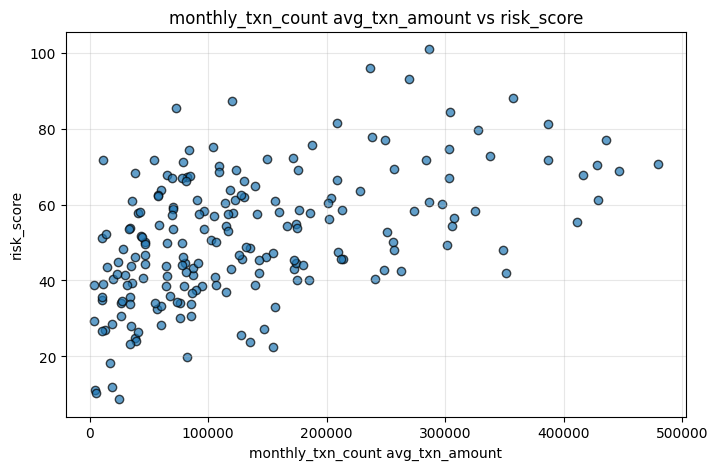

In [131]:
import matplotlib.pyplot as plt

# pick one polynomial feature (change index if needed)
feature = polynomial_features[0]

plt.figure(figsize=(8, 5))
plt.scatter(df2[feature], df2["risk_score"], alpha=0.7, edgecolor="k")
plt.title(f"{feature} vs risk_score")
plt.xlabel(feature)
plt.ylabel("risk_score")
plt.grid(True, alpha=0.3)
plt.show()

##### Checking if its Linear or non Linear 

Feature: monthly_txn_count avg_txn_amount
R² (linear):    0.2517
R² (quadratic): 0.2699
Conclusion: relationship is mostly linear (or weakly non-linear).


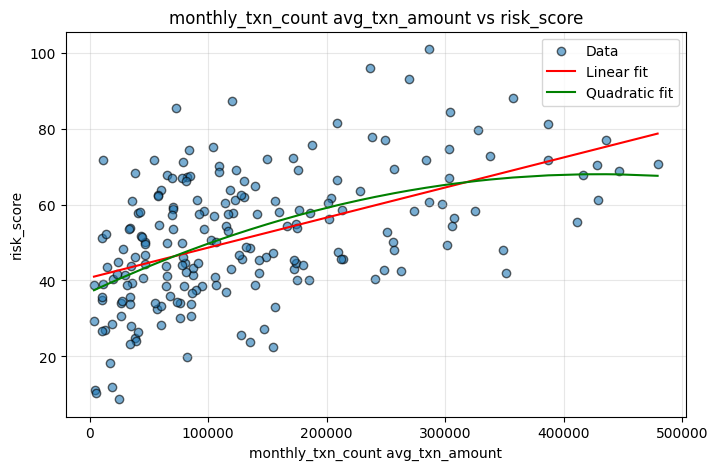

In [132]:
x = df2[[feature]].values
y = df2["risk_score"].values

# Linear fit
lin_model = LinearRegression().fit(x, y)
r2_linear = lin_model.score(x, y)

# Quadratic (curved) fit
x_quad = np.hstack([x, x**2])
quad_model = LinearRegression().fit(x_quad, y)
r2_quadratic = quad_model.score(x_quad, y)

print(f"Feature: {feature}")
print(f"R² (linear):    {r2_linear:.4f}")
print(f"R² (quadratic): {r2_quadratic:.4f}")

if r2_quadratic > r2_linear + 0.02:
    print("Conclusion: relationship looks curved (non-linear).")
else:
    print("Conclusion: relationship is mostly linear (or weakly non-linear).")

# Optional visualization
order = np.argsort(x[:, 0])
x_sorted = x[order]
y_sorted = y[order]

plt.figure(figsize=(8, 5))
plt.scatter(x, y, alpha=0.6, edgecolor="k", label="Data")
plt.plot(x_sorted, lin_model.predict(x_sorted), color="red", label="Linear fit")
plt.plot(
    x_sorted,
    quad_model.predict(np.hstack([x_sorted, x_sorted**2])),
    color="green",
    label="Quadratic fit",
)
plt.title(f"{feature} vs risk_score")
plt.xlabel(feature)
plt.ylabel("risk_score")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [133]:
pd.DataFrame(df2.columns)

,0
0,risk_score
1,monthly_txn_count
2,avg_txn_amount
3,cross_border_ratio
4,cash_deposit_ratio
5,account_age_months
6,monthly_txn_count avg_txn_amount
7,monthly_txn_count cross_border_ratio
8,monthly_txn_count cash_deposit_ratio
9,monthly_txn_count account_age_months


In [134]:
recommended_features = df2[[
    # Core drivers
    "risk_score",
    "monthly_txn_count",
    "avg_txn_amount",
    "cross_border_ratio",
    "cash_deposit_ratio",
    "account_age_months",
    "deposit_behavior",
    # Useful interaction terms (already in df2 as polynomial features)
    "monthly_txn_count avg_txn_amount",
    "monthly_txn_count cross_border_ratio",
    "monthly_txn_count cash_deposit_ratio",
    "avg_txn_amount cross_border_ratio",
    "avg_txn_amount cash_deposit_ratio",
    "cross_border_ratio cash_deposit_ratio",
]]

In [135]:
recommended_features.head()

,risk_score,monthly_txn_count,avg_txn_amount,cross_border_ratio,cash_deposit_ratio,account_age_months,deposit_behavior,monthly_txn_count avg_txn_amount,monthly_txn_count cross_border_ratio,monthly_txn_count cash_deposit_ratio,avg_txn_amount cross_border_ratio,avg_txn_amount cash_deposit_ratio,cross_border_ratio cash_deposit_ratio
0,54.378744,122.0,940.242412,0.688500,0.411255,74.0,Balanced,114709.574313,83.996988,50.173124,647.356808,386.679503,0.283149
1,38.469092,199.0,475.958853,0.058194,0.777602,67.0,Cash Heavy,94715.811667,11.580526,154.742855,27.697757,370.106691,0.045251
2,58.220420,112.0,862.194398,0.915214,0.480370,83.0,Balanced,96565.772610,102.503938,53.801449,789.092150,414.172394,0.439641
3,63.852578,34.0,1772.396505,0.442352,0.985286,122.0,Cash Heavy,60261.481170,15.039976,33.499726,784.023546,1746.317553,0.435843
4,30.603238,126.0,682.472791,0.239787,0.376739,125.0,Balanced,85991.571666,30.213207,47.469110,163.648348,257.114096,0.090337


In [136]:
features = recommended_features.drop('risk_score',axis=1)
target = recommended_features[['risk_score']]

##### Feature Scaling to standadize Data

In [137]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# keep original structure, scale only numeric columns
feaures_scaled = features.copy()
numeric_cols = feaures_scaled.select_dtypes(include=[np.number]).columns

feaures_scaled[numeric_cols] = scaler.fit_transform(feaures_scaled[numeric_cols])

# optional: use scaled features in next cells
features = feaures_scaled.copy()

feaures_scaled.head()

,monthly_txn_count,avg_txn_amount,cross_border_ratio,cash_deposit_ratio,account_age_months,deposit_behavior,monthly_txn_count avg_txn_amount,monthly_txn_count cross_border_ratio,monthly_txn_count cash_deposit_ratio,avg_txn_amount cross_border_ratio,avg_txn_amount cash_deposit_ratio,cross_border_ratio cash_deposit_ratio
0,-0.162632,-0.129715,0.641309,-0.312533,-0.401821,Balanced,-0.178577,0.323233,-0.271221,0.308096,-0.276783,0.141976
1,0.963003,-0.970935,-1.549188,0.987833,-0.544891,Cash Heavy,-0.364938,-1.006045,1.665463,-1.145399,-0.313666,-0.948645
2,-0.308819,-0.271127,1.429205,-0.067206,-0.217875,Balanced,-0.347695,0.662947,-0.204023,0.640555,-0.215597,0.859401
3,-1.449072,1.378037,-0.214126,1.725017,0.579227,Cash Heavy,-0.686086,-0.942543,-0.580021,0.628666,2.749103,0.841990
4,-0.104158,-0.596759,-0.918097,-0.435050,0.640543,Balanced,-0.446257,-0.664023,-0.321301,-0.826508,-0.565132,-0.741953


In [138]:
X = feaures_scaled.copy()
y= target.copy()

In [139]:
y.head()

,risk_score
0,54.378744
1,38.469092
2,58.220420
3,63.852578
4,30.603238


In [140]:
X.head()

,monthly_txn_count,avg_txn_amount,cross_border_ratio,cash_deposit_ratio,account_age_months,deposit_behavior,monthly_txn_count avg_txn_amount,monthly_txn_count cross_border_ratio,monthly_txn_count cash_deposit_ratio,avg_txn_amount cross_border_ratio,avg_txn_amount cash_deposit_ratio,cross_border_ratio cash_deposit_ratio
0,-0.162632,-0.129715,0.641309,-0.312533,-0.401821,Balanced,-0.178577,0.323233,-0.271221,0.308096,-0.276783,0.141976
1,0.963003,-0.970935,-1.549188,0.987833,-0.544891,Cash Heavy,-0.364938,-1.006045,1.665463,-1.145399,-0.313666,-0.948645
2,-0.308819,-0.271127,1.429205,-0.067206,-0.217875,Balanced,-0.347695,0.662947,-0.204023,0.640555,-0.215597,0.859401
3,-1.449072,1.378037,-0.214126,1.725017,0.579227,Cash Heavy,-0.686086,-0.942543,-0.580021,0.628666,2.749103,0.841990
4,-0.104158,-0.596759,-0.918097,-0.435050,0.640543,Balanced,-0.446257,-0.664023,-0.321301,-0.826508,-0.565132,-0.741953


##### Since our data is Ordinal we implement Label encding, If it were Norminal we use One hot encoding

In [141]:
X.deposit_behavior.value_counts(dropna=False)


deposit_behavior
Balanced          78
Cash Heavy        66
Mostly Digital    56
Name: count, dtype: int64

In [142]:
from sklearn.preprocessing import LabelEncoder

le_deposit_behavior = LabelEncoder()
X["deposit_behavior"] = le_deposit_behavior.fit_transform(X["deposit_behavior"])

# optional: view encoded class mapping
deposit_behavior_mapping = dict(
    zip(le_deposit_behavior.classes_, le_deposit_behavior.transform(le_deposit_behavior.classes_))
)
print(deposit_behavior_mapping)

X.head()

{'Balanced': np.int64(0), 'Cash Heavy': np.int64(1), 'Mostly Digital': np.int64(2)}


,monthly_txn_count,avg_txn_amount,cross_border_ratio,cash_deposit_ratio,account_age_months,deposit_behavior,monthly_txn_count avg_txn_amount,monthly_txn_count cross_border_ratio,monthly_txn_count cash_deposit_ratio,avg_txn_amount cross_border_ratio,avg_txn_amount cash_deposit_ratio,cross_border_ratio cash_deposit_ratio
0,-0.162632,-0.129715,0.641309,-0.312533,-0.401821,0,-0.178577,0.323233,-0.271221,0.308096,-0.276783,0.141976
1,0.963003,-0.970935,-1.549188,0.987833,-0.544891,1,-0.364938,-1.006045,1.665463,-1.145399,-0.313666,-0.948645
2,-0.308819,-0.271127,1.429205,-0.067206,-0.217875,0,-0.347695,0.662947,-0.204023,0.640555,-0.215597,0.859401
3,-1.449072,1.378037,-0.214126,1.725017,0.579227,1,-0.686086,-0.942543,-0.580021,0.628666,2.749103,0.841990
4,-0.104158,-0.596759,-0.918097,-0.435050,0.640543,0,-0.446257,-0.664023,-0.321301,-0.826508,-0.565132,-0.741953


In [143]:
X.deposit_behavior.value_counts(dropna=False)

deposit_behavior
0    78
1    66
2    56
Name: count, dtype: int64

In [144]:
# pd.get_dummies(X, columns=['deposit_behavior'], prefix='deposit_behavior', dummy_na=True).head() this is for one hot encoding but we will use label encoding for this feature as it is ordinal in nature.

In [145]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

In [146]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [147]:
X_train.shape,X_test.shape,y_train.shape,y_test.shape,X.shape,y.shape

((160, 12), (40, 12), (160, 1), (40, 1), (200, 12), (200, 1))

In [148]:
X_train.shape[0]/X.shape[0],y_train.shape[0]/y.shape[0]

(0.8, 0.8)

In [149]:
X_test.shape[0]/X.shape[0],y_test.shape[0]/y.shape[0]

(0.2, 0.2)

In [150]:
model = LinearRegression()
model.fit(X_train,y_train)

LinearRegression()

In [151]:
y_pred = model.predict(X_test)
y_pred[:10]

array([[64.58109417],
       [39.17209744],
       [56.23502397],
       [11.77906463],
       [66.61402956],
       [58.81004844],
       [42.99538878],
       [45.83200539],
       [74.68272455],
       [67.65505016]])

In [152]:
y_test[:10]

,risk_score
95,66.343679
15,48.583911
30,50.634941
158,8.725277
128,69.174853
115,57.002388
69,38.512584
170,41.572205
174,81.297452
45,75.594228


In [153]:
comparison_df = y_test.copy().rename(columns={"risk_score": "actual"})
comparison_df["predicted"] = y_pred.flatten()
comparison_df["difference"] = comparison_df["actual"] - comparison_df["predicted"]

comparison_df.head(10)

,actual,predicted,difference
95,66.343679,64.581094,1.762584
15,48.583911,39.172097,9.411814
30,50.634941,56.235024,-5.600083
158,8.725277,11.779065,-3.053788
128,69.174853,66.614030,2.560824
115,57.002388,58.810048,-1.807660
69,38.512584,42.995389,-4.482805
170,41.572205,45.832005,-4.259801
174,81.297452,74.682725,6.614728
45,75.594228,67.655050,7.939177


In [154]:
from sklearn.metrics import mean_squared_error, r2_score

In [155]:
mse = mean_squared_error(y_test, y_pred)
mse

29.718726666690667

In [156]:
r2_score(y_test, y_pred)

0.8973214395114824

In [157]:
# Compare model performance with vs without feature scaling
# (same train/test rows, same features, same label encoding)

# 1) Build unscaled feature set
X_unscaled = recommended_features[X.columns].copy()
X_unscaled["deposit_behavior"] = le_deposit_behavior.transform(X_unscaled["deposit_behavior"])

# 2) Use the exact same split indices as current scaled experiment
train_idx = y_train.index
test_idx = y_test.index

X_train_unscaled = X_unscaled.loc[train_idx]
X_test_unscaled = X_unscaled.loc[test_idx]

# 3) Train/evaluate unscaled model
model_unscaled = LinearRegression()
model_unscaled.fit(X_train_unscaled, y_train)
y_pred_unscaled = model_unscaled.predict(X_test_unscaled)

mse_unscaled = mean_squared_error(y_test, y_pred_unscaled)
r2_unscaled = r2_score(y_test, y_pred_unscaled)

# 4) Reuse scaled model predictions from current notebook
mse_scaled = mean_squared_error(y_test, y_pred)
r2_scaled = r2_score(y_test, y_pred)

print("Scaled model   -> MSE:", round(mse_scaled, 6), " R²:", round(r2_scaled, 6))
print("Unscaled model -> MSE:", round(mse_unscaled, 6), " R²:", round(r2_unscaled, 6))
print("Delta (scaled - unscaled) -> MSE:", round(mse_scaled - mse_unscaled, 10),
    " R²:", round(r2_scaled - r2_unscaled, 10))

if abs(r2_scaled - r2_unscaled) < 1e-8 and abs(mse_scaled - mse_unscaled) < 1e-8:
    print("Conclusion: Feature scaling did not materially help LinearRegression performance.")
elif r2_scaled > r2_unscaled:
    print("Conclusion: Feature scaling helped slightly.")
else:
    print("Conclusion: Feature scaling did not help (or slightly reduced performance).")

Scaled model   -> MSE: 29.718727  R²: 0.897321
Unscaled model -> MSE: 29.718727  R²: 0.897321
Delta (scaled - unscaled) -> MSE: -0.0  R²: 0.0
Conclusion: Feature scaling did not materially help LinearRegression performance.


In [160]:
# Quick numerical check: scaled vs unscaled predictions are effectively identical
pred_diff_max = np.max(np.abs(y_pred.flatten() - y_pred_unscaled.flatten()))
r2_diff = abs(r2_scaled - r2_unscaled)

print(f"Max |prediction difference|: {pred_diff_max:.16f}")
print(f"|R² difference|: {r2_diff:.16f}")

if pred_diff_max < 1e-10 and r2_diff < 1e-10:
    print("Conclusion: No practical performance gain from scaling for unregularized LinearRegression.")

Max |prediction difference|: 0.0000000000117879
|R² difference|: 0.0000000000000148
Conclusion: No practical performance gain from scaling for unregularized LinearRegression.


In [158]:
# R² manual calculation using SST and SSR

y_true = y_test["risk_score"].values
y_hat = y_pred.flatten()

y_mean = y_true.mean()

# SST: Total Sum of Squares -> total variability in actual values around their mean
SST = np.sum((y_true - y_mean) ** 2)

# SSR: Regression Sum of Squares -> variability explained by predictions
SSR = np.sum((y_hat - y_mean) ** 2)

# SSE: Error (Residual) Sum of Squares -> unexplained variability
SSE = np.sum((y_true - y_hat) ** 2)

# Two equivalent forms of R²
r2_from_ssr_sst = SSR / SST
r2_from_sse_sst = 1 - (SSE / SST)

print(f"SST (total variation): {SST:.6f}")
print(f"SSR (explained variation): {SSR:.6f}")
print(f"SSE (unexplained variation): {SSE:.6f}")
print(f"Check: SST ≈ SSR + SSE -> {SST:.6f} ≈ {(SSR + SSE):.6f}\n")

print(f"R² = SSR / SST        = {r2_from_ssr_sst:.6f}")
print(f"R² = 1 - SSE / SST    = {r2_from_sse_sst:.6f}")
print(f"R² (sklearn r2_score) = {r2_score(y_test, y_pred):.6f}")

SST (total variation): 11577.383448
SSR (explained variation): 10462.403440
SSE (unexplained variation): 1188.749067
Check: SST ≈ SSR + SSE -> 11577.383448 ≈ 11651.152507

R² = SSR / SST        = 0.903693
R² = 1 - SSE / SST    = 0.897321
R² (sklearn r2_score) = 0.897321


In [159]:
END

NameError: name 'END' is not defined

In [ ]:
# features = df2.drop('risk_score',axis=1)
# target = df2[['risk_score']]

In [ ]:
# # list the polynomial features in the dataset
# polynomial_features = [col for col in df.columns if 'poly' in col]
# polynomial_features

[]

In [ ]:
ssssa

NameError: name 'ssssa' is not defined

In [ ]:
# # Create a copy to avoid modifying the original dataframe
# df_text = df.copy()

# # Add text-based features
# df_text["risk_level"] = pd.cut(
#     df_text["risk_score"],
#     bins=[-np.inf, 35, 55, np.inf],
#     labels=["Low", "Medium", "High"]
# ).astype(str)

# df_text["txn_amount_segment"] = pd.qcut(
#     df_text["avg_txn_amount"],
#     q=3,
#     labels=["Small", "Medium", "Large"]
# ).astype(str)

# df_text["border_activity"] = np.select(
#     [
#         df_text["cross_border_ratio"] < 0.33,
#         df_text["cross_border_ratio"] < 0.66
#     ],
#     ["Low", "Moderate"],
#     default="High"
# )

# df_text["deposit_behavior"] = np.select(
#     [
#         df_text["cash_deposit_ratio"] < 0.33,
#         df_text["cash_deposit_ratio"] < 0.66
#     ],
#     ["Mostly Digital", "Balanced"],
#     default="Cash Heavy"
# )

# df_text["customer_profile"] = (
#     df_text["risk_level"] + " risk | " +
#     df_text["txn_amount_segment"] + " txn | " +
#     df_text["border_activity"] + " border"
# )

# # Save new datasets
# csv_path = "../feed/TrainTestSplit/Risk_Score_with_text_features.csv"
# excel_path = "../feed/TrainTestSplit/Risk_Score_with_text_features.xlsx"

# df_text.to_csv(csv_path, index=False)
# df_text.to_excel(excel_path, index=False)

# print("Saved:")
# print(csv_path)
# print(excel_path)
# df_text.head()

In [ ]:
# from sklearn.preprocessing import PolynomialFeatures

# # Base numeric features (exclude target)
# base_features = [
#     "monthly_txn_count",
#     "avg_txn_amount",
#     "cross_border_ratio",
#     "cash_deposit_ratio",
#     "account_age_months",
# ]

# X = df[base_features]

# # Add polynomial features (degree=2 gives more numeric columns)
# poly = PolynomialFeatures(degree=2, include_bias=False)
# X_poly = poly.fit_transform(X)
# poly_cols = poly.get_feature_names_out(base_features)
# df_poly = pd.DataFrame(X_poly, columns=poly_cols, index=df.index)

# # Avoid multicollinearity by dropping highly correlated columns
# corr_matrix = df_poly.corr().abs()
# upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
# to_drop = [col for col in upper.columns if any(upper[col] > 0.95)]

# df_poly_reduced = df_poly.drop(columns=to_drop)

# # Final dataset: keep target + reduced polynomial features
# df_poly_final = pd.concat([df[["risk_score"]], df_poly_reduced], axis=1)

# # Save new datasets
# poly_csv_path = "../feed/TrainTestSplit/Risk_Score_with_polynomial_features_reduced.csv"
# poly_excel_path = "../feed/TrainTestSplit/Risk_Score_with_polynomial_features_reduced.xlsx"

# df_poly_final.to_csv(poly_csv_path, index=False)
# df_poly_final.to_excel(poly_excel_path, index=False)

# print("Saved:")
# print(poly_csv_path)
# print(poly_excel_path)
# print(f"Original polynomial columns: {df_poly.shape[1]}")
# print(f"Removed for multicollinearity: {len(to_drop)}")
# print(f"Final columns (including risk_score): {df_poly_final.shape[1]}")

# df_poly_final.head()

In [ ]:
# # Add text features to the reduced polynomial dataset
# df_poly_text = df_poly_final.copy()

# df_poly_text["risk_level"] = pd.cut(
#     df_poly_text["risk_score"],
#     bins=[-np.inf, 35, 55, np.inf],
#     labels=["Low", "Medium", "High"]
# ).astype(str)

# df_poly_text["txn_amount_segment"] = pd.qcut(
#     df_poly_text["avg_txn_amount"],
#     q=3,
#     labels=["Small", "Medium", "Large"]
# ).astype(str)

# df_poly_text["border_activity"] = np.select(
#     [
#         df_poly_text["cross_border_ratio"] < 0.33,
#         df_poly_text["cross_border_ratio"] < 0.66
#     ],
#     ["Low", "Moderate"],
#     default="High"
# )

# df_poly_text["deposit_behavior"] = np.select(
#     [
#         df_poly_text["cash_deposit_ratio"] < 0.33,
#         df_poly_text["cash_deposit_ratio"] < 0.66
#     ],
#     ["Mostly Digital", "Balanced"],
#     default="Cash Heavy"
# )

# df_poly_text["customer_profile"] = (
#     df_poly_text["risk_level"] + " risk | " +
#     df_poly_text["txn_amount_segment"] + " txn | " +
#     df_poly_text["border_activity"] + " border"
# )

# # Save updated dataset
# poly_text_csv_path = "../feed/TrainTestSplit/Risk_Score_with_polynomial_features_reduced_text.csv"
# poly_text_excel_path = "../feed/TrainTestSplit/Risk_Score_with_polynomial_features_reduced_text.xlsx"

# df_poly_text.to_csv(poly_text_csv_path, index=False)
# df_poly_text.to_excel(poly_text_excel_path, index=False)

# print("Saved:")
# print(poly_text_csv_path)
# print(poly_text_excel_path)

# df_poly_text.head()